# Kaggle Competition Notebook

**Author:** Er. Ankur Kumar

**LinkedIn:** [Ankur Kumar](https://linkedin.com/in/ankur-kumar-198031287)

**GitHub:** [Ankurkumar2005](https://github.com/Ankurkumar2005)

## Import labraies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

In [3]:
df_train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15788494.0,Chu,591.0,Spain,Male,30.0,4.0,112419.92,1.0,0.0,0.0,88890.05,0.0
1,1,15743893.0,Ch'ang,544.0,Spain,Female,47.0,1.0,0.00,1.0,1.0,0.0,80120.19,1.0
2,2,15738884.0,Mancini,705.0,France,Male,37.0,9.0,0.00,2.0,1.0,1.0,79919.13,0.0
3,3,15795586.0,Chikelu,670.0,France,Male,40.0,10.0,0.00,2.0,1.0,1.0,55835.66,0.0
4,4,15586518.0,Tsou,714.0,Spain,Female,46.0,1.0,107879.06,1.0,1.0,0.0,162697.93,0.0


In [4]:
df_test.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15686936.0,Ting,537.0,France,Female,53.0,4.0,0.00,2.0,1.0,1.0,119712.78
1,15001,15733032.0,K?,652.0,France,Female,39.0,9.0,0.00,1.0,1.0,0.0,54164.01
2,15002,15674928.0,Hsieh,675.0,France,Male,49.0,5.0,0.00,2.0,0.0,1.0,132973.21
3,15003,15783030.0,Mancini,753.0,Germany,Male,51.0,5.0,127864.40,1.0,0.0,1.0,183868.01
4,15004,15752953.0,Walker,627.0,Germany,Male,35.0,4.0,126663.51,2.0,1.0,0.0,79616.37


In [5]:
submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [7]:
df_train.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,7499.500000,1.571083e+07,657.576267,37.690333,5.015800,42391.092967,1.586000,0.782133,0.497733,1.172384e+05,0.202267
std,4330.271354,1.637345e+06,72.135924,8.125600,2.804724,59657.264519,0.529864,0.412810,0.500012,4.672902e+04,0.401703
min,0.000000,1.567894e+06,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.477300e+02,0.000000
25%,3749.750000,1.563557e+07,601.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,8.246369e+04,0.000000
50%,7499.500000,1.569054e+07,660.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,1.224886e+05,0.000000
75%,11249.250000,1.575787e+07,708.000000,42.000000,7.000000,108910.382500,2.000000,1.000000,1.000000,1.558885e+05,0.000000
max,14999.000000,1.581198e+08,850.000000,72.000000,10.000000,187911.550000,4.000000,1.000000,1.000000,1.387001e+06,1.000000


In [9]:
df_train.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
cat_cols = ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'Exited']

num_cols = ['CreditScore', 'Age', 'Balance','EstimatedSalary']

# Find the value counts of the categorical columns
for col in cat_cols:
    print(df_train[col].value_counts())
    print()

# Find the value counts of the categorical columns
for col1 in num_cols:
    print(df_train[col1].value_counts())
    print()

Geography
France     8946
Spain      3338
Germany    2716
Name: count, dtype: int64

Gender
Male      8515
Female    6485
Name: count, dtype: int64

Tenure
2.0     1692
7.0     1668
4.0     1623
9.0     1551
3.0     1547
8.0     1546
1.0     1520
5.0     1493
6.0     1407
10.0     529
0.0      424
Name: count, dtype: int64

NumOfProducts
2.0    8308
1.0    6466
3.0     196
4.0      30
Name: count, dtype: int64

HasCrCard
1.0    11732
0.0     3268
Name: count, dtype: int64

IsActiveMember
0.0    7534
1.0    7466
Name: count, dtype: int64

Exited
0.0    11966
1.0     3034
Name: count, dtype: int64

CreditScore
678.0    253
684.0    199
705.0    169
683.0    166
850.0    159
        ... 
821.0      1
513.0      1
768.0      1
453.0      1
491.0      1
Name: count, Length: 371, dtype: int64

Age
37.0    872
34.0    845
35.0    841
38.0    839
36.0    820
33.0    813
39.0    777
40.0    740
32.0    699
31.0    682
41.0    611
29.0    599
30.0    495
43.0    491
42.0    485
28.0    395
44.0 

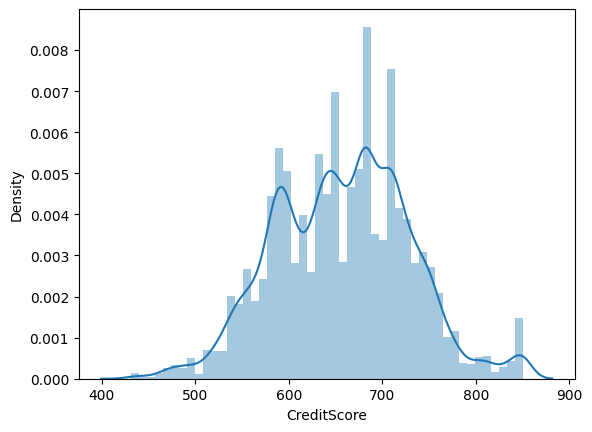

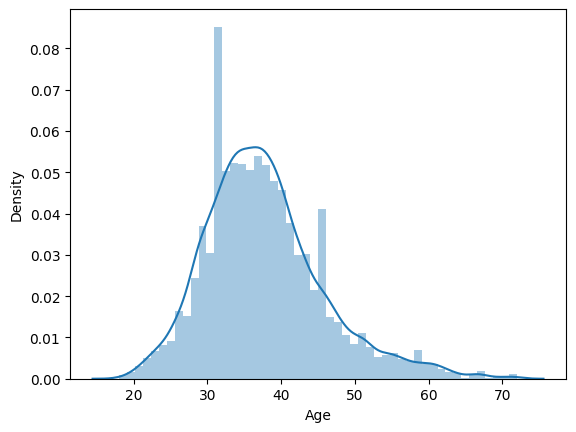

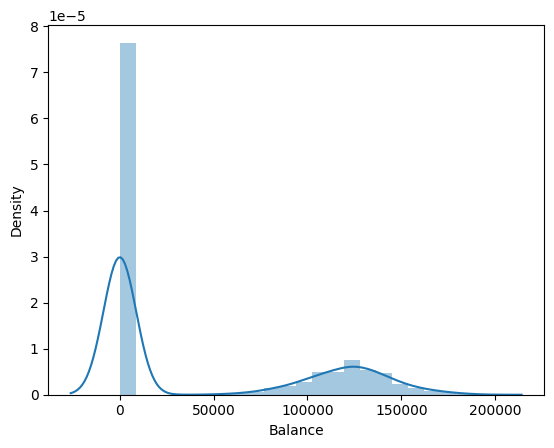

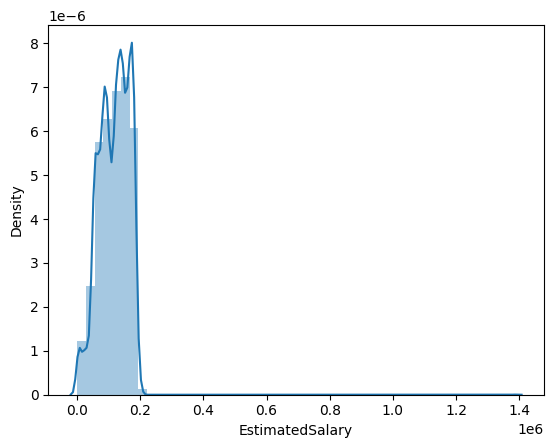

In [11]:
# Create histogram of numerical columns using sns and kde=True
for col1 in num_cols:
    sns.distplot(df_train[col1], kde=True)
    plt.show()

In [28]:
# Split the data into X and y
X = df_train.drop([
    'Exited',
    'Surname',
    'CustomerId',
    'id'
], axis=1)
y = df_train['Exited']

# Split the data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [29]:
X = pd.get_dummies(
    X,
    columns=['Geography', 'Gender'],
    drop_first=True
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# Encode the categorical columns having object datatypes using label encoder'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_train['Geography'] = le.fit_transform(df_train['Geography'])
df_train['Gender'] = le.fit_transform(df_train['Gender'])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,591.0,2,1,30.0,4,112419.92,0,0,0,88890.05
1,544.0,2,0,47.0,1,0.00,0,1,0,80120.19
2,705.0,0,1,37.0,9,0.00,1,1,1,79919.13
3,670.0,0,1,40.0,10,0.00,1,1,1,55835.66
4,714.0,2,0,46.0,1,107879.06,0,1,0,162697.93


In [22]:
y.head()

0    0.0
1    1.0
2    0.0
3    0.0
4    0.0
Name: Exited, dtype: float64

In [23]:
y.value_counts()

Exited
0.0    11966
1.0     3034
Name: count, dtype: int64

In [33]:
# Create a deep neural network using tensorflow for binary classification
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu',input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
# Defint the callback function
early_dtopping = EarlyStopping(patience=15)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# training the model
history = model.fit(X_train,y_train, epochs=5, batch_size=32, verbose=1, validation_data=(X_test,y_test), callbacks=[early_stopping])

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8569 - loss: 0.3463 - val_accuracy: 0.8923 - val_loss: 0.2622
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8876 - loss: 0.2746 - val_accuracy: 0.8990 - val_loss: 0.2440
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8927 - loss: 0.2642 - val_accuracy: 0.8963 - val_loss: 0.2462
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8934 - loss: 0.2610 - val_accuracy: 0.9007 - val_loss: 0.2444
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8957 - loss: 0.2562 - val_accuracy: 0.9033 - val_loss: 0.2434
Restoring model weights from the end of the best epoch: 5.


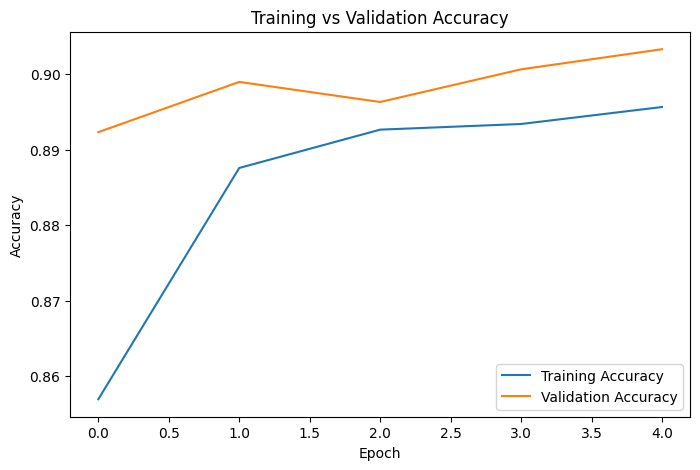

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

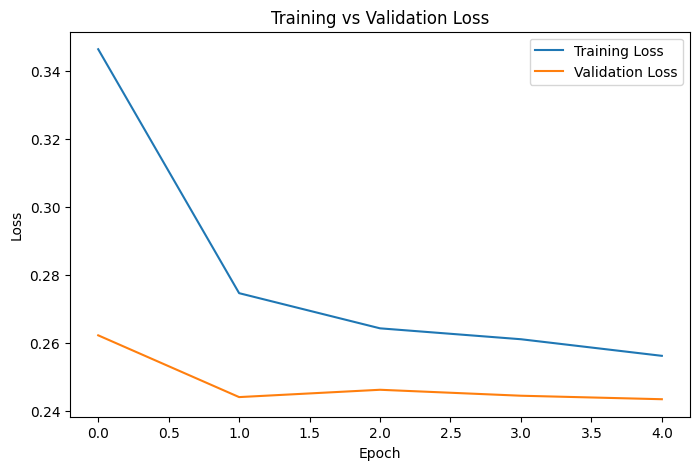

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# XGB calssifier

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Train the XGBoost model
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Predict on test data
y_pred = xgb.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.896
Precision: 0.7748
Recall   : 0.6706
F1 Score : 0.7189


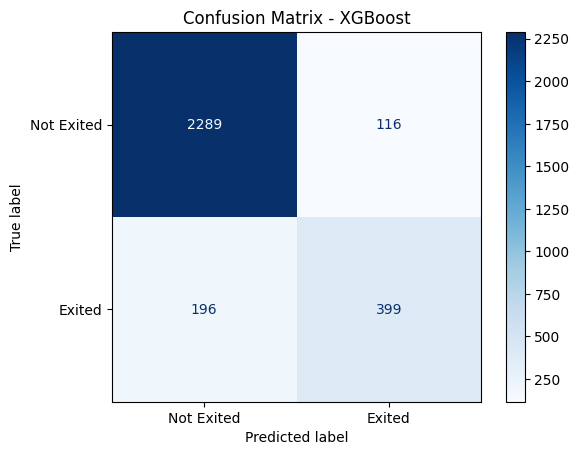

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Exited', 'Exited']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical columns to numerical values
le = LabelEncoder()

df_test['Geography'] = le.fit_transform(df_test['Geography'])
df_test['Gender'] = le.fit_transform(df_test['Gender'])


# Predict the test data and create a submission file of probability of each class
y_pred = xgb.predict_proba(df_test.drop(['id','CustomerId','Surname'], axis=1))
submission['Exited'] = y_pred[:,1]
submission.to_csv('submission.csv', index=False)